# MSE 446 Random Forest
### What household factors are most likely to affect energy usage and financial struggle?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

## Load Pre-Cleaned Data
From John's data prep script

In [2]:
X_train = pd.read_csv("clean_x_train.csv")
X_test  = pd.read_csv("clean_x_test.csv")
y_train = pd.read_csv("clean_y_train.csv")
y_test  = pd.read_csv("clean_y_test.csv")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (14564, 646)
X_test:  (3642, 646)
y_train: (14564, 11)
y_test:  (3642, 11)


In [3]:
# Split y into regression and classification targets
regression_targets  = ["DOLLAREL", "DOLLARNG", "DOLLARFO", "DOLLARLP"]
categorical_targets = ["SCALEB", "SCALEG", "SCALEE", "PAYHELP", "ENERGYASST", "COLDMA", "HOTMA"]

y_reg_train = y_train[regression_targets]
y_reg_test  = y_test[regression_targets]
y_cat_train = y_train[categorical_targets]
y_cat_test  = y_test[categorical_targets]

## Regression — Predicting Energy Costs
Targets: `DOLLAREL`, `DOLLARNG`, `DOLLARFO`, `DOLLARLP`  
Metrics: MAE, RMSE, R²

In [4]:
reg_models = {}
reg_scores = {}

for col in regression_targets:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,        # grow full trees
        min_samples_leaf=5,    # prevent overfitting
        max_features='sqrt',   # random feature subsets per split
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_reg_train[col])
    preds = model.predict(X_test)

    reg_models[col] = model
    reg_scores[col] = {
        "MAE":  mean_absolute_error(y_reg_test[col], preds),
        "RMSE": np.sqrt(mean_squared_error(y_reg_test[col], preds)),
        "R2":   r2_score(y_reg_test[col], preds)
    }

print("=== Regression (Random Forest) ===")
for col, s in reg_scores.items():
    print(f"{col}: MAE={s['MAE']:.2f}, RMSE={s['RMSE']:.2f}, R\u00b2={s['R2']:.3f}")

print()
print(pd.DataFrame(reg_scores).T.round(3).to_string())

=== Regression (Random Forest) ===
DOLLAREL: MAE=445.37, RMSE=653.22, R²=0.433
DOLLARNG: MAE=121.33, RMSE=241.51, R²=0.742
DOLLARFO: MAE=43.68, RMSE=204.06, R²=0.777
DOLLARLP: MAE=47.09, RMSE=182.69, R²=0.713

              MAE     RMSE     R2
DOLLAREL  445.373  653.221  0.433
DOLLARNG  121.328  241.505  0.742
DOLLARFO   43.681  204.064  0.777
DOLLARLP   47.086  182.691  0.713


## Classification — Predicting Energy Struggle Indicators
Targets: `SCALEB`, `SCALEG`, `SCALEE`, `PAYHELP`, `ENERGYASST`, `COLDMA`, `HOTMA`  
Metrics: Accuracy, F1, Precision, Recall  
Note: `class_weight='balanced'` used to handle class imbalance in struggle indicators.

In [5]:
cat_models = {}
cat_scores = {}

for col in categorical_targets:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',  # corrects for class imbalance in struggle indicators
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_cat_train[col])
    preds = model.predict(X_test)

    cat_models[col] = model
    cat_scores[col] = {
        "Accuracy":  accuracy_score(y_cat_test[col], preds),
        "F1":        f1_score(y_cat_test[col], preds, average='weighted', zero_division=0),
        "Precision": precision_score(y_cat_test[col], preds, average='weighted', zero_division=0),
        "Recall":    recall_score(y_cat_test[col], preds, average='weighted', zero_division=0)
    }

print("=== Classification (Random Forest) ===")
for col, s in cat_scores.items():
    print(f"{col}: Accuracy={s['Accuracy']:.3f}, F1={s['F1']:.3f}, "
          f"Precision={s['Precision']:.3f}, Recall={s['Recall']:.3f}")

print()
print(pd.DataFrame(cat_scores).T.round(3).to_string())

=== Classification (Random Forest) ===
SCALEB: Accuracy=0.811, F1=0.776, Precision=0.746, Recall=0.811
SCALEG: Accuracy=0.912, F1=0.870, Precision=0.832, Recall=0.912
SCALEE: Accuracy=0.912, F1=0.875, Precision=0.865, Recall=0.912
PAYHELP: Accuracy=0.912, F1=0.877, Precision=0.869, Recall=0.912
ENERGYASST: Accuracy=0.955, F1=0.934, Precision=0.939, Recall=0.955
COLDMA: Accuracy=0.992, F1=0.988, Precision=0.985, Recall=0.992
HOTMA: Accuracy=0.995, F1=0.993, Precision=0.991, Recall=0.995

            Accuracy     F1  Precision  Recall
SCALEB         0.811  0.776      0.746   0.811
SCALEG         0.912  0.870      0.832   0.912
SCALEE         0.912  0.875      0.865   0.912
PAYHELP        0.912  0.877      0.869   0.912
ENERGYASST     0.955  0.934      0.939   0.955
COLDMA         0.992  0.988      0.985   0.992
HOTMA          0.995  0.993      0.991   0.995


## Hyperparameter Tuning — GridSearchCV on SCALEB
SCALEB (difficulty paying energy bills) is our primary classification target of interest.

In [6]:
clf = RandomForestClassifier(
    class_weight='balanced',
    random_state=156
)

params = {
    'max_depth':    np.arange(5, 30, 5),
    'n_estimators': np.arange(50, 210, 50)
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1_weighted',   # f1_weighted is more informative than accuracy for imbalanced targets
    return_train_score=True
)
grid_search.fit(X_train, y_cat_train["SCALEB"])

print("Best params for SCALEB:", grid_search.best_params_)

# Replace default SCALEB model with tuned one
cat_models["SCALEB"] = grid_search.best_estimator_
tuned_preds = grid_search.best_estimator_.predict(X_test)

print("\n=== Tuned SCALEB Metrics ===")
print(f"  Accuracy:  {accuracy_score(y_cat_test['SCALEB'], tuned_preds):.3f}")
print(f"  F1:        {f1_score(y_cat_test['SCALEB'], tuned_preds, average='weighted', zero_division=0):.3f}")
print(f"  Precision: {precision_score(y_cat_test['SCALEB'], tuned_preds, average='weighted', zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_cat_test['SCALEB'], tuned_preds, average='weighted', zero_division=0):.3f}")
print("\nDetailed Classification Report:")
print(classification_report(y_cat_test["SCALEB"], tuned_preds, zero_division=0))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params for SCALEB: {'max_depth': np.int64(10), 'n_estimators': np.int64(150)}

=== Tuned SCALEB Metrics ===
  Accuracy:  0.759
  F1:        0.762
  Precision: 0.773
  Recall:    0.759

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      3037
           1       0.16      0.28      0.20       149
           2       0.17      0.25      0.21       252
           3       0.19      0.04      0.06       204

    accuracy                           0.76      3642
   macro avg       0.35      0.36      0.34      3642
weighted avg       0.77      0.76      0.76      3642



## Feature Importance
Gini importance (Mean Decrease in Impurity) — already computed inside Random Forest, no extra calculation needed.

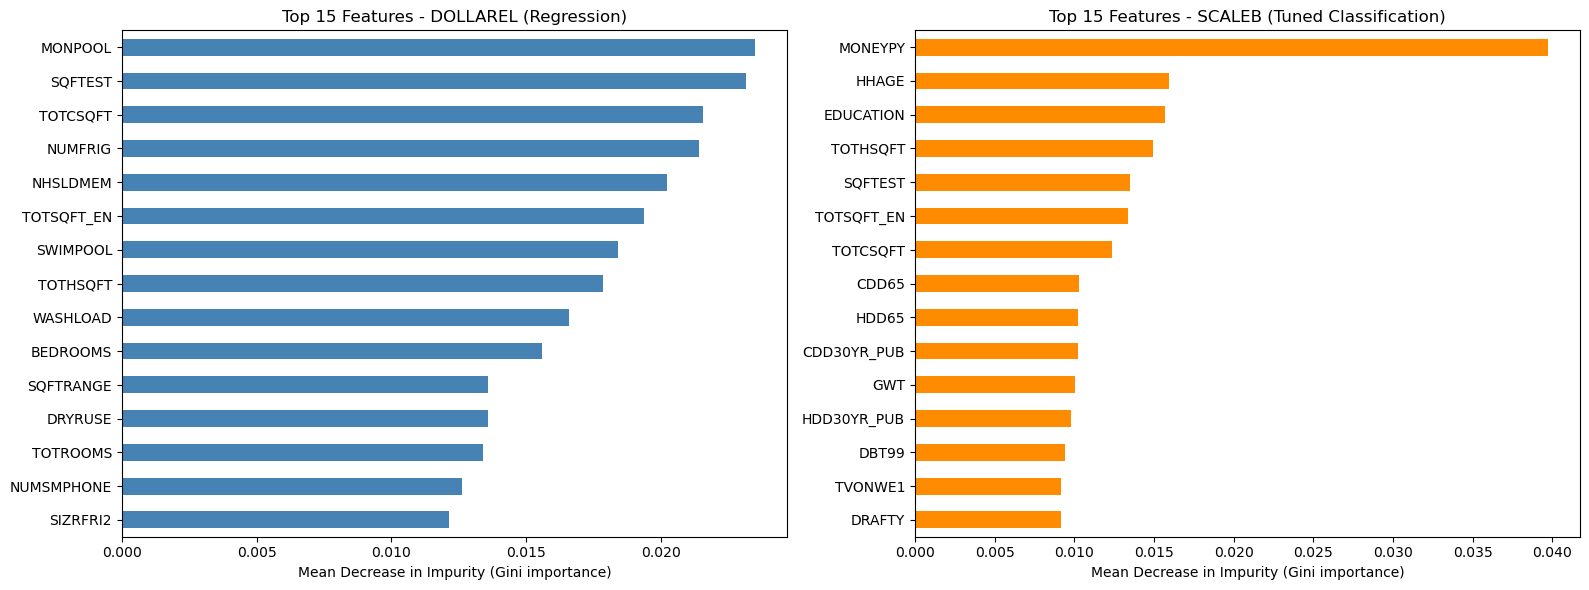

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features for DOLLAREL (Regression)
reg_importances = pd.Series(
    reg_models["DOLLAREL"].feature_importances_, index=X_train.columns
).nlargest(15)
reg_importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Top 15 Features - DOLLAREL (Regression)")
axes[0].set_xlabel("Mean Decrease in Impurity (Gini importance)")

# Top 15 features for SCALEB (tuned)
cat_importances = pd.Series(
    cat_models["SCALEB"].feature_importances_, index=X_train.columns
).nlargest(15)
cat_importances.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("Top 15 Features - SCALEB (Tuned Classification)")
axes[1].set_xlabel("Mean Decrease in Impurity (Gini importance)")

plt.tight_layout()
plt.show()

# Findings
## What household factors affect energy usage and financial struggle?

**DOLLAREL (Regression) — predicts electricity cost in dollars:**
- Square footage (`SQFTEST`, `TOTCSQFT`) is the dominant driver
- Household size (`NHSLDMEM`), dryer use (`DRYRUSE`), and pool (`MONPOOL`, `SWIMPOOL`) also matter

**SCALEB (Classification) — predicts difficulty paying energy bills:**
- Income (`MONEYPY`) is by far the strongest predictor
- Age of householder (`HHAGE`), home quality (`DRAFTY`), climate (`HDD65`, `CDD65`), and education level all contribute

**Key observation:** Struggle to pay bills is driven primarily by socioeconomic factors (income, age, education),
while actual energy consumption is driven primarily by physical home characteristics (size, appliances, climate).
 